In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score
import pandas as pd
from PIL import Image
import numpy as np
import os
from pathlib import Path
import random

# =========================
# 設定
# =========================
DATA_DIR = Path("/mnt/data1/Public/MedImages/DermMel")
TRAIN_IMG_DIR = DATA_DIR / "train_sep"
VAL_IMG_DIR = DATA_DIR / "valid"
TEST_IMG_DIR = DATA_DIR / "test"

# DermMel はフォルダ名がクラス名になっている構造を想定
# train_sep/
# ├── Melanoma/
# └── NotMelanoma/
# valid/
# ├── Melanoma/
# └── NotMelanoma/
# test/（ラベルなし想定）

# =========================
# データ変換（Data Augmentation）
# =========================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# =========================
# Dataset定義
# =========================
class ImageFolderWithLabel(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {"NotMelanoma": 0, "Melanoma": 1}

        for cls in self.class_to_idx.keys():
            class_dir = Path(root_dir) / cls
            files = list(class_dir.glob("*.*"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cls]))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# =========================
# Dataset & DataLoader
# =========================
train_dataset = ImageFolderWithLabel(TRAIN_IMG_DIR, train_transform)
val_dataset = ImageFolderWithLabel(VAL_IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# =========================
# モデル定義
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 1)  # 2クラス→1出力 (sigmoid)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# =========================
# EarlyStopping（モデル保存機能付き）
# =========================
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, save_path="best_model.pth"):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0
        self.delta = delta
        self.best_model = None
        self.save_path = save_path  # 追加

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.best_model = model.state_dict()
            torch.save(self.best_model, self.save_path)
            if self.verbose:
                print(f"✅ Best model saved (acc: {val_acc:.4f})")
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model = model.state_dict()
            torch.save(self.best_model, self.save_path)
            if self.verbose:
                print(f"✅ Best model updated (acc: {val_acc:.4f})")
            self.counter = 0



In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/kaggle/path/DermMel_best_resnet50.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/kaggle/path/DermMel_best_resnet50.pth


In [3]:
import torch
import torch.nn as nn

# --- 攻撃関数 ---
import torch.nn.functional as F

import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

# 前提: device, mean, std が外部で定義されている（投稿の定義をそのまま使えます）
# MEAN = np.array([...]); STD = np.array([...])
# mean = torch.tensor(MEAN).view(1,3,1,1).to(device)
# std  = torch.tensor(STD).view(1,3,1,1).to(device)

def denormalize(x, mean, std):
    # normalized -> pixel [0,1]
    return x * std + mean

def renormalize(x_pixel, mean, std):
    # pixel [0,1] -> normalized
    return (x_pixel - mean) / std

def fgsm_attack_improved(model, images, labels, epsilon_pixel, device,
                         mean_tensor=None, std_tensor=None, return_preds=True):
    """
    FGSM attack that respects per-channel normalization.
    Args:
      model: nn.Module, expects normalized inputs (same normalization used here)
      images: normalized tensor [B,C,H,W] (already normalized by mean/std)
      labels: tensor [B] (0/1) or shape [B,1]
      epsilon_pixel: float (e.g. 8/255) or tensor broadcastable to channels (pixel-scale)
      device: torch.device
      mean_tensor, std_tensor: tensors shaped [1,C,1,1] on device (if None, must be global)
      return_preds: if True, also return predicted labels on adversarial images
    Returns:
      adv_images: tensor [B,C,H,W] (normalized, detached)
      adv_preds (optional): LongTensor [B] predicted labels on adv_images (cpu)
    """
    # use provided mean/std or expect global variables `mean`/`std`
    if mean_tensor is None or std_tensor is None:
        # these should exist in your scope (as in your snippet)
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    # model output: assume logits for binary classification -> shape [B] or [B,1]
    outputs = model(images)
    if outputs.ndim > 1 and outputs.shape[1] == 1:
        outputs = outputs.squeeze(1)  # [B]
    # binary cross entropy with logits
    loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
    model.zero_grad()
    loss.backward()
    grad = images.grad.data  # gradient in normalized space

    # sign of gradient in normalized space
    grad_sign = grad.sign()

    # convert epsilon_pixel (pixel scale: 0..1) -> normalized-space epsilon per channel
    # support scalar epsilon_pixel or iterable per-channel
    if not torch.is_tensor(epsilon_pixel):
        eps_pixel_tensor = torch.tensor(epsilon_pixel, dtype=images.dtype, device=device)
    else:
        eps_pixel_tensor = epsilon_pixel.to(device).to(images.dtype)

    # make eps_norm shaped [1,C,1,1]
    if eps_pixel_tensor.ndim == 0:
        eps_norm = (eps_pixel_tensor / std_tensor_local).view(1, -1, 1, 1)
    elif eps_pixel_tensor.ndim == 1 and eps_pixel_tensor.numel() == std_tensor_local.shape[1]:
        eps_norm = (eps_pixel_tensor.view(1, -1, 1, 1) / std_tensor_local)
    else:
        # fallback: try to broadcast
        eps_norm = (eps_pixel_tensor / std_tensor_local)

    # create adversarial images in normalized space
    adv_images = images + eps_norm * grad_sign

    # clamp in pixel space
    adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
    adv_pixel = torch.clamp(adv_pixel, 0.0, 1.0)

    # back to normalized space
    adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    adv_images.requires_grad = False

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        # cleanup
        del grad, grad_sign, adv_out, adv_pixel, eps_norm, eps_pixel_tensor, loss
        torch.cuda.empty_cache()
        return adv_images, adv_preds

    # cleanup
    del grad, grad_sign, adv_pixel, eps_norm, eps_pixel_tensor, loss
    torch.cuda.empty_cache()
    return adv_images


# --- 評価関数 ---
def evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel, mean, std):
    adv_correct, adv_total = 0, 0
    orig_correct, orig_total = 0, 0
    processed = 0
    max_samples = 100  # ← 100枚に制限

    model.eval()
    for images, labels in val_loader:
        if processed >= max_samples:
            break  # ← 100枚に達したら終了
        images, labels = images.to(device), labels.to(device)

        # 元画像での予測
        outputs = model(images)
        if outputs.ndim > 1 and outputs.shape[1] == 1:
            outputs = outputs.squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).long()

        correct_mask = (preds == labels.long())
        if correct_mask.sum() == 0:
            continue

        correct_images = images[correct_mask]
        correct_labels = labels[correct_mask]

        orig_preds = preds[correct_mask]
        orig_correct += (orig_preds == correct_labels).sum().item()
        orig_total += correct_labels.size(0)

        # FGSM攻撃（正規化対応版）
        adv_images, adv_preds = fgsm_attack_improved(
            model, correct_images, correct_labels, epsilon_pixel, device,
            mean_tensor=mean, std_tensor=std, return_preds=True
        )
        adv_correct += (adv_preds == correct_labels.cpu()).sum().item()
        adv_total += correct_labels.size(0)

    orig_acc = orig_correct / orig_total * 100 if orig_total > 0 else 0
    adv_acc = adv_correct / adv_total * 100 if adv_total > 0 else 0
    print(f"Original Accuracy (on selected correct samples): {orig_acc:.2f}% ({orig_correct}/{orig_total})")
    print(f"Adversarial Accuracy (on originally correct samples): {adv_acc:.2f}% ({adv_correct}/{adv_total})")
    return orig_acc, adv_acc




In [8]:
evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel=30/255, mean=mean, std=std)

Original Accuracy (on selected correct samples): 100.00% (3426/3426)
Adversarial Accuracy (on originally correct samples): 60.71% (2080/3426)


(100.0, 60.71220081727963)

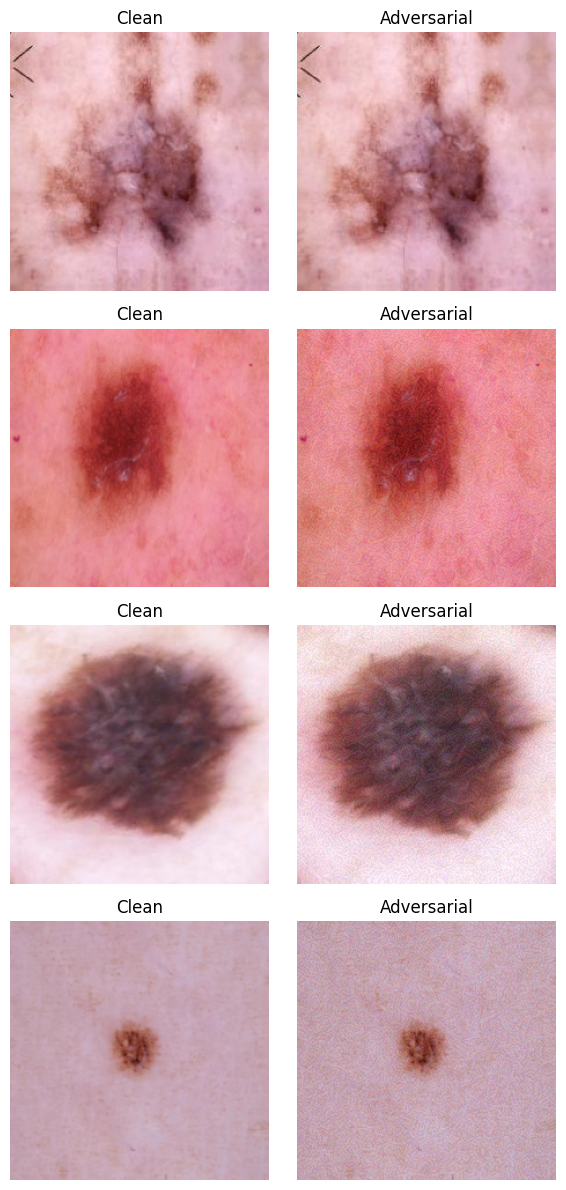

In [ ]:
"""import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch

# --- 設定 ---
num_display = 4  # 先頭何枚を可視化するか

# 表示用 unnormalize（正規化 -> pixel [0,1]）
def unnormalize_tensor(x):
    return x * std.to(x.device) + mean.to(x.device)

# データを少しだけ取得
it = iter(val_loader)
collected = 0
rows = []

while collected < num_display:
    try:
        batch = next(it)
    except StopIteration:
        break
    images, labels = batch
    B = images.shape[0]
    take = min(B, num_display - collected)
    imgs = images[:take].to(device)
    labs = labels[:take].to(device)

    # FGSM攻撃
    adv_images, adv_preds = fgsm_attack_improved(
        model, imgs, labs, epsilon_pixel=8/255, device=device,
        mean_tensor=mean, std_tensor=std, return_preds=True
    )

    rows.append({
        "clean": imgs.detach().cpu(),
        "adv": adv_images.detach().cpu()
    })

    collected += take

# --- 描画 ---
plt.figure(figsize=(6, 3 * num_display))
idx = 0
for r in rows:
    B = r["clean"].shape[0]
    for i in range(B):
        # 元画像
        plt.subplot(num_display, 2, idx * 2 + 1)
        img_clean = unnormalize_tensor(r["clean"][i].to(device)).cpu()
        if img_clean.ndim == 4:
            img_clean = img_clean.squeeze(0)
        plt.imshow(TF.to_pil_image(img_clean))
        plt.title("Clean")
        plt.axis("off")

        # 敵対画像
        plt.subplot(num_display, 2, idx * 2 + 2)
        img_adv = unnormalize_tensor(r["adv"][i].to(device)).cpu()
        if img_adv.ndim == 4:
            img_adv = img_adv.squeeze(0)
        plt.imshow(TF.to_pil_image(img_adv))
        plt.title("Adversarial")
        plt.axis("off")

        idx += 1

plt.tight_layout()
plt.show()"""


In [9]:
# fgsm_plus_diffusion_eval.py
import os
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from torchvision import transforms, datasets, models
import torch.nn as nn
import torchvision
import math
import sys
sys.path.append("/mnt/data1/gotou/projects/guided-diffusion")  # クローンした場所に置き換え

from guided_diffusion import dist_util, logger
from guided_diffusion.script_util import create_model_and_diffusion


# --- guided-diffusion imports (make sure repo is available in PYTHONPATH) ---
from guided_diffusion import dist_util, logger
from guided_diffusion.script_util import create_model_and_diffusion

from guided_diffusion import dist_util, logger
from guided_diffusion.script_util import (
    model_and_diffusion_defaults,
    create_model_and_diffusion
)

# ---------------- user settings ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64 # VRAM に合わせて調整。256x256 diffusion は重いので小さめ推奨
epsilon = 0.01
num_samples = 100 # correct_top1_images.txt の先頭何枚を使うか

# Diffusion settings
use_ddim = True
ddim_steps = 100     # 速くしたければ 25~50。品質を優先するなら 100+
real_step = 30     # reverse の深さ（実験して調整）
blend_alpha = 0.6
model_path = "/mnt/data1/gotou/projects/guided-diffusion/256x256_diffusion_uncond.pt"  # 事前チェックポイント


# ---------------- transforms (あなたの分類用) ----------------
# 既存の分類 transform と同じものを使う想定
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# ImageNet 正規化パラ
imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3,1,1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(3,1,1)

# ---------------- load classifier ----------------
clf = models.resnet50(pretrained=True).to(device)
clf.eval()

# ---------------- load paths ----------------
with open("correct_image_paths.txt") as f:
    all_paths = [p.strip() for p in f]
paths = all_paths[:num_samples]

# ---------------- guided-diffusion model load ----------------
defaults = model_and_diffusion_defaults()
defaults.update({
    "image_size": 256,
    "num_channels": 256,
    "num_res_blocks": 2,
    "num_heads": 4,
    "num_head_channels": -1,
    "learn_sigma": True,
    "class_cond": False,
    "use_fp16": False,
    "use_scale_shift_norm": True,
    "resblock_updown": True,
    "attention_resolutions": "32,16,8",
    "diffusion_steps": 1000,
    "timestep_respacing": f"ddim{ddim_steps}" if use_ddim else "1000",  # ★追加
})

print("Creating guided-diffusion model...")
diff_model, diffusion = create_model_and_diffusion(**defaults)

print("Loading checkpoint:", model_path)
ckpt = torch.load(model_path, map_location="cpu")
diff_model.load_state_dict(ckpt)

diff_model.to(device)
diff_model.eval()
print("✅ Model loaded successfully!")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'correct_image_paths.txt'